In [2]:
import json
import glob
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

from postprocessing import postprocess, topics_subtopics, topics_subtopics_flatten

In [8]:
class ReviewEvaluator:
    def __init__(self, all_topics, all_sentiments):
        """
        Инициализация оценщика
        
        Args:
            all_topics (list): Все возможные темы
            all_sentiments (list): Все возможные тональности
        """
        self.all_topics = all_topics
        self.all_sentiments = all_sentiments
        
    def prepare_topic_data(self, data):
        """
        Преобразует данные в бинарные векторы для multi-label классификации тем
        """
        y_binary = np.zeros((len(data), len(self.all_topics)), dtype=int)
        
        for i, review in enumerate(data):
            for topic_dict in review:
                topic = topic_dict['topic']
                if topic in self.all_topics:
                    idx = self.all_topics.index(topic)
                    y_binary[i, idx] = 1
                    
        return y_binary
    
    def prepare_sentiment_data(self, true_data, pred_data):
        """
        Собирает пары (тема, тональность) для правильно предсказанных тем
        """
        true_sentiments = []
        pred_sentiments = []
        
        for true_review, pred_review in zip(true_data, pred_data):
            # Преобразуем в множества для сравнения
            true_topics_set = set(item['topic'] for item in true_review)
            pred_topics_set = set(item['topic'] for item in pred_review)
            
            # Находим пересечение - правильно предсказанные темы
            correct_topics = true_topics_set & pred_topics_set
            
            for topic in correct_topics:
                # Находим соответствующие тональности
                true_sent = next(item['sentiment'] for item in true_review if item['topic'] == topic)
                pred_sent = next(item['sentiment'] for item in pred_review if item['topic'] == topic)
                
                true_sentiments.append(true_sent)
                pred_sentiments.append(pred_sent)
                
        return true_sentiments, pred_sentiments
    
    def evaluate(self, true_data, pred_data, model_name="Model"):
        """
        Полная оценка модели
        """
        # print(f"=== Оценка модели: {model_name} ===")
        
        # 1. Оценка тем (Multi-label F1 Micro)
        y_true_topics = self.prepare_topic_data(true_data)
        y_pred_topics = self.prepare_topic_data(pred_data)
        
        topic_f1_micro = f1_score(y_true_topics, y_pred_topics, average='micro', zero_division=0)
        topic_f1_macro = f1_score(y_true_topics, y_pred_topics, average='macro', zero_division=0)
        
        # print(f"\n--- Оценка определения тем ---")
        # print(f"F1 Micro: {topic_f1_micro:.4f}")
        # print(f"F1 Macro: {topic_f1_macro:.4f}")
        
        # # Детальный отчет по темам
        # print(f"\nДетальный отчет по темам:")
        # topic_report = classification_report(
        #     y_true_topics, y_pred_topics, 
        #     target_names=self.all_topics, 
        #     zero_division=0
        # )
        # print(topic_report)
        
        # 2. Оценка тональности (Accuracy)
        true_sentiments, pred_sentiments = self.prepare_sentiment_data(true_data, pred_data)
        
        sentiment_accuracy = accuracy_score(true_sentiments, pred_sentiments)
        # print(f"\n--- Оценка анализа тональности ---")
        # print(f"Accuracy (только для правильных тем): {sentiment_accuracy:.4f}")
        # print(f"Количество примеров для оценки: {len(true_sentiments)}")
        
        # 3. Confusion Matrix для тональности
        # self.plot_confusion_matrix(true_sentiments, pred_sentiments, model_name)
        
        # Детальный отчет по тональности
        # print(f"\nДетальный отчет по тональности:")
        # sentiment_report = classification_report(
        #     true_sentiments, pred_sentiments, 
        #     target_names=self.all_sentiments,
        #     zero_division=0
        # )
        # print(sentiment_report)

        
        return {
            'topic_f1_micro': topic_f1_micro,
            'topic_f1_macro': topic_f1_macro,
            'sentiment_accuracy': sentiment_accuracy if true_sentiments else 0
        }
    
    def plot_confusion_matrix(self, true_sentiments, pred_sentiments, model_name):
        """
        Строит и отображает confusion matrix для тональности
        """
        cm = confusion_matrix(true_sentiments, pred_sentiments, labels=self.all_sentiments)
        
        # plt.figure(figsize=(8, 6))
        # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        #            xticklabels=self.all_sentiments,
        #            yticklabels=self.all_sentiments)
        # plt.title(f'Confusion Matrix - {model_name}\n(только для правильных тем)')
        # plt.xlabel('Предсказанная тональность')
        # plt.ylabel('Истинная тональность')
        # plt.tight_layout()
        # plt.show()
        
        # Выводим normalized confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=self.all_sentiments,
                   yticklabels=self.all_sentiments)
        plt.title(f'Normalized Confusion Matrix - {model_name}\n(только для правильных тем)')
        plt.xlabel('Предсказанная тональность')
        plt.ylabel('Истинная тональность')
        plt.tight_layout()
        plt.show()
        
        return cm

## testing

In [30]:
dataset_path = "data/dataset_v2.json"

with open(dataset_path) as f:
    dataset = json.load(f)

In [31]:
dataset_postprocess = postprocess(dataset, return_subtopics=False)

In [32]:
id_dataset_dict = {sample["id"] : sample["topic_sentiment_pairs"] for sample in dataset}
dataset_ids = list(id_dataset_dict.keys())

In [33]:
id_dataset_dict[1]

[{'topic': 'Дебетовые карты', 'sentiment': 'neutral'},
 {'topic': 'Денежные переводы', 'sentiment': 'neutral'},
 {'topic': 'Дистанционное обслуживание', 'sentiment': 'positive'}]

In [63]:
model_name = "qwen2.5_0.5b-reviews-fine-tune-v1"
# model_name = "gemma3-270m-it-reviews-v3"
# model_name = "qwen3_0.6b-reviews-fine-tune-v3"
# topics_sentiments_json = "data/synthetic_dataset/synthetic_data_prompt_v2.json"
topics_sentiments_json = f"data/inference/inference_results_{model_name}.json"
# topics_sentiments_json = "data/synthetic_dataset/synthetic_data_prompt_v2.json"
# topics_sentiments_json = "data/inference/inference_results_qwen3_0.6b-reviews-fine-tune-v3.json"
original_reviews_csv = "data/reviews_our_time.csv"

with open(topics_sentiments_json) as f:
    inference_result = json.load(f)

inference_metadata = inference_result["metadata"]

original_reviews_df = pd.read_csv(original_reviews_csv)

In [64]:
inference_result_postprocessed = postprocess(inference_result["results"], return_subtopics=False)

In [65]:
inference_result_postprocessed[0]

{'id': 24937,
 'topic_sentiment_pairs': [{'topic': 'Вклады', 'sentiment': 'negative'}]}

In [66]:
id_inference_result_dict = {sample["id"] : sample["topic_sentiment_pairs"] for sample in inference_result_postprocessed}
inference_result = list(id_dataset_dict.keys())

In [67]:
json.loads('[{"a" : 2}]')

[{'a': 2}]

In [68]:
true_data = []
pred_data = []
for review_id in dataset_ids:
    true_data.append(id_dataset_dict[review_id])
    pred_data.append(id_inference_result_dict[review_id])

In [69]:
true_data[0], pred_data[0]

([{'topic': 'Дебетовые карты', 'sentiment': 'negative'},
  {'topic': 'Денежные переводы', 'sentiment': 'neutral'},
  {'topic': 'Дистанционное обслуживание', 'sentiment': 'negative'},
  {'topic': 'Офисное обслуживание', 'sentiment': 'negative'}],
 [{'topic': 'Дебетовые карты', 'sentiment': 'negative'},
  {'topic': 'Дистанционное обслуживание', 'sentiment': 'negative'}])

In [70]:
len(true_data), len(pred_data)

(11511, 11511)

=== Оценка модели: qwen2.5_0.5b-reviews-fine-tune-v1 ===

--- Оценка определения тем ---
F1 Micro: 0.8387
F1 Macro: 0.7490

Детальный отчет по темам:
                                   precision    recall  f1-score   support

             Офисное обслуживание       0.92      0.66      0.77      3292
                        Банкоматы       0.90      0.70      0.79       310
       Дистанционное обслуживание       0.93      0.77      0.84      6484
                  Дебетовые карты       0.91      0.82      0.87      5838
         Курьерская доставка карт       0.93      0.80      0.86      1667
                  Кредитные карты       0.97      0.90      0.93      1864
                           Вклады       0.93      0.73      0.82       972
                          Кредиты       0.81      0.68      0.74       355
                      Автокредиты       0.81      0.89      0.85        44
   Страховые и сервисные продукты       0.81      0.75      0.78       483
                        

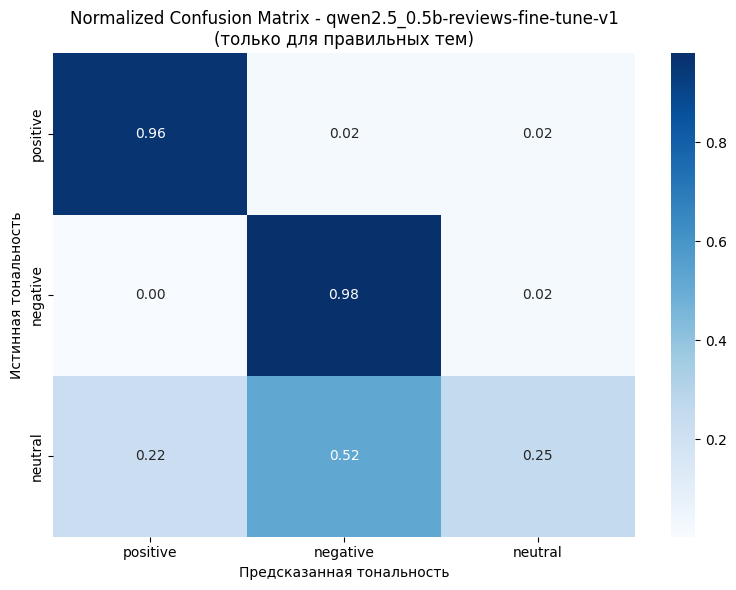

Запросов в секунду: 12.092156236297585

Итоговые метрики: {'topic_f1_micro': 0.8386810061327882, 'topic_f1_macro': 0.7490283044825871, 'sentiment_accuracy': 0.926494277236117}


0.8650249874637868

In [75]:
all_topics = list(topics_subtopics.keys())
all_sentiments = ['positive', 'negative', 'neutral']

# Создаем оценщик и запускаем оценку
evaluator = ReviewEvaluator(all_topics, all_sentiments)
metrics = evaluator.evaluate(true_data, pred_data, model_name)

print("Запросов в секунду:", inference_metadata["total_requests"] / inference_metadata["total_time_seconds"])

print(f"\nИтоговые метрики: {metrics}")
metrics["topic_f1_micro"] * 0.7 + metrics["sentiment_accuracy"] * 0.3

In [5]:
def calculate_metrics(dataset_path, model_name):
    topics_sentiments_json = f"data/inference/inference_results_{model_name}.json"

    with open(dataset_path) as f:
        dataset = json.load(f)

    dataset_postprocess = postprocess(dataset, return_subtopics=False)
    id_dataset_dict = {sample["id"] : sample["topic_sentiment_pairs"] for sample in dataset_postprocess}
    dataset_ids = list(id_dataset_dict.keys())

    with open(topics_sentiments_json) as f:
        inference_result = json.load(f)

    inference_metadata = inference_result["metadata"]

    inference_result_postprocessed = postprocess(inference_result["results"], return_subtopics=False)

    id_inference_result_dict = {sample["id"] : sample["topic_sentiment_pairs"] for sample in inference_result_postprocessed}
    inference_result = list(id_dataset_dict.keys())

    true_data = []
    pred_data = []
    for review_id in dataset_ids:
        true_data.append(id_dataset_dict[review_id])
        pred_data.append(id_inference_result_dict[review_id])

    all_topics = list(topics_subtopics.keys())
    all_sentiments = ['positive', 'neutral', 'negative']

    evaluator = ReviewEvaluator(all_topics, all_sentiments)
    metrics = evaluator.evaluate(true_data, pred_data, model_name)
    
    metrics["request_per_second"] = inference_metadata["total_requests"] / inference_metadata["total_time_seconds"]
    
    metrics["score"] = metrics["topic_f1_micro"] * 0.7 + metrics["sentiment_accuracy"] * 0.3

    return metrics

## collecting

In [16]:
# model_name = "qwen2.5_0.5b-reviews-fine-tune-v1"
# model_name = "gemma3-270m-it-reviews-v2"
# model_name = "gemma3-270m-it-reviews-v3"
# model_name = "qwen3_0.6b-reviews-fine-tune-v3"
model_name = "qwen3_0.6b-reviews-fine-tune-v4"

calculate_metrics(dataset_path = "data/dataset_v2.json", 
                  model_name = model_name)

{'topic_f1_micro': 0.8401253918495298,
 'topic_f1_macro': 0.7376983797732546,
 'sentiment_accuracy': 0.9282433983926521,
 'request_per_second': 7.8561559695102865,
 'score': 0.8665607938124664}

In [20]:
gemma3_v3_metrics = calculate_metrics(dataset_path = "data/dataset_v2.json", model_name = "gemma3-270m-it-reviews-v3")

qwen25_v1_metrics = calculate_metrics(dataset_path = "data/dataset_v2.json", model_name = "qwen2.5_0.5b-reviews-fine-tune-v1")

qwen3_v3_metrics = calculate_metrics(dataset_path = "data/dataset_v2.json", model_name = "qwen3_0.6b-reviews-fine-tune-v3")

qwen3_v4_metrics = calculate_metrics(dataset_path = "data/dataset_v2.json", model_name = "qwen3_0.6b-reviews-fine-tune-v4")


In [21]:
pd.DataFrame(
    {
        "gemma3_v3" : gemma3_v3_metrics,
        "qwen2.5_v1" : qwen25_v1_metrics,
        "qwen3_v3" : qwen3_v3_metrics,
        "qwen3_v4" : qwen3_v4_metrics
    }
).T

,topic_f1_micro,topic_f1_macro,sentiment_accuracy,request_per_second,score
gemma3_v3,0.781263,0.655486,0.911570,16.215559,0.820355
qwen2.5_v1,0.838681,0.749028,0.926494,12.092156,0.865025
qwen3_v3,0.897883,0.842991,0.928186,6.859683,0.906974
qwen3_v4,0.840125,0.737698,0.928243,7.856156,0.866561


| Модель       | F1-micro (темы) | F1-macro (темы) | Точность (тональность) | Запросов/секунду | Score |
|--------------|-----------------|-----------------|------------------------|------------------|------------|
| gemma3    | 0.781           | 0.655           | 0.912                  | 16.216           | 0.820      |
| qwen2.5   | 0.839           | 0.749           | 0.926                  | 12.092           | 0.865      |
| qwen3     | 0.898           | 0.843           | 0.928                  | 6.860            | 0.907      |

| Модель     | Topic F1-micro | Topic F1-macro | Sentiment Acc. | Requests/sec    | Score  |
|------------|---------------|---------------|---------------|--------|--------|
| gemma3_v3  | 0.781         | 0.655         | 0.912         | 16.216 | 0.820  |
| qwen2.5_v1 | 0.839         | 0.749         | 0.926         | 12.092 | 0.865  |
| qwen3_v3   | 0.898         | 0.843         | 0.928         | 6.860  | 0.907  |

Requests/sec 